# Linear Regression


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## 3. Nonlinear 非線性的  

$$f(x) = \sin(3.2x) + 0.8x$$


### 3. 生成假資料

In [2]:
x = np.linspace(0, 5, 100)
y = np.sin(3.2*x)+ 0.8*x + 0.3*np.random.randn(100)

In [10]:
x

array([0.        , 0.05050505, 0.1010101 , 0.15151515, 0.2020202 ,
       0.25252525, 0.3030303 , 0.35353535, 0.4040404 , 0.45454545,
       0.50505051, 0.55555556, 0.60606061, 0.65656566, 0.70707071,
       0.75757576, 0.80808081, 0.85858586, 0.90909091, 0.95959596,
       1.01010101, 1.06060606, 1.11111111, 1.16161616, 1.21212121,
       1.26262626, 1.31313131, 1.36363636, 1.41414141, 1.46464646,
       1.51515152, 1.56565657, 1.61616162, 1.66666667, 1.71717172,
       1.76767677, 1.81818182, 1.86868687, 1.91919192, 1.96969697,
       2.02020202, 2.07070707, 2.12121212, 2.17171717, 2.22222222,
       2.27272727, 2.32323232, 2.37373737, 2.42424242, 2.47474747,
       2.52525253, 2.57575758, 2.62626263, 2.67676768, 2.72727273,
       2.77777778, 2.82828283, 2.87878788, 2.92929293, 2.97979798,
       3.03030303, 3.08080808, 3.13131313, 3.18181818, 3.23232323,
       3.28282828, 3.33333333, 3.38383838, 3.43434343, 3.48484848,
       3.53535354, 3.58585859, 3.63636364, 3.68686869, 3.73737

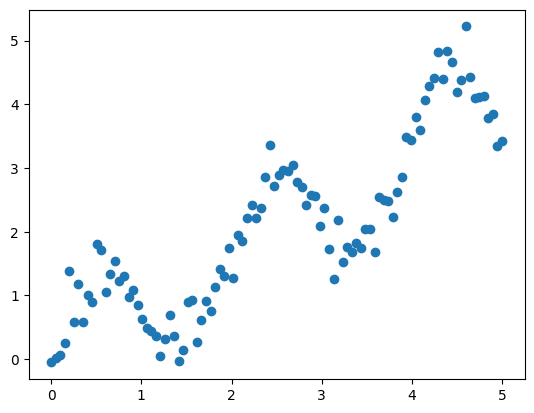

In [3]:
plt.scatter(x,y)

#### nonlinear

In [4]:
regr_lin = LinearRegression()

In [5]:
X = x.reshape(-1, 1)
print(X.shape)

(100, 1)


In [6]:
regr_lin.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


0.4989949775676724


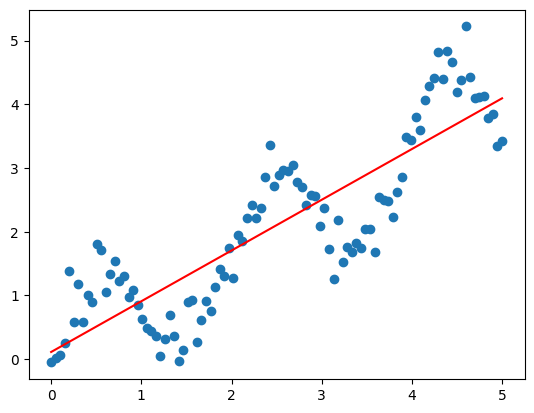

In [16]:
y_pred = regr_lin.predict(X)
plt.scatter(x, y)
plt.plot(x, y_pred, color='r')
mse = np.sum((y_pred-y)**2) / len(y)
print(mse)

果然超級不準, 該如何是好?

#### 多項式

多項式5次方

$$\widehat{y}=xw+b=w_{1}x_{1}+w_{2}x_{1}^{2}+w_{3}x_{1}^{3}+w_{4}x_{1}^{4}+w_{5}x_{1}^{5}+b$$

In [11]:
print(x.shape)

(100,)


In [12]:
X_poly = np.array([[k, k**2, k**3, k**4, k**5] for k in x])  # add k**6 to try it
print(X_poly.shape) # -> 從 1維 變 5維（機器學習維度(features)，在 5維 空間中實際是一條直線，!= 5Darray）

(100, 5)


In [11]:
regr_poly = LinearRegression() # 等於幫我補上 b(bias)

In [13]:
regr_poly.fit(X_poly, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# 直接使用 PolynomialFeatures 寫法
# preprocessing（前處理）
# feature engineering（特徵工程）

# from sklearn.preprocessing import PolynomialFeatures # 設定「要產生到幾次方」的特徵
# poly = PolynomialFeatures(degree=5)
# X_poly = poly.fit_transform(x.reshape(-1, 1))

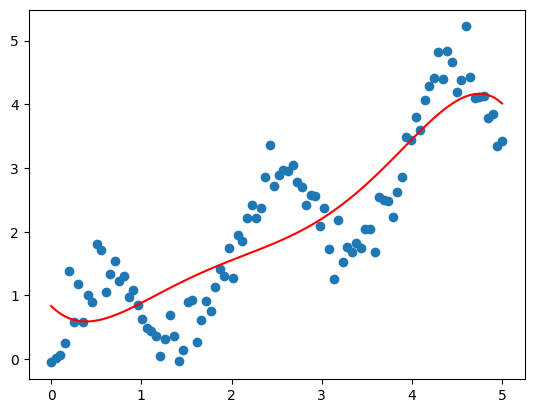

In [15]:
plt.scatter(x,y)
plt.plot(x, regr_poly.predict(X_poly), 'r')

In [26]:
mse = np.sum((regr_poly.predict(X_poly)-y)**2) / len(y)
print(mse)

0.44529099471624756


In [18]:
print('Coefficients: ', regr_poly.coef_)
print('interception: ', regr_poly.intercept_)

Coefficients:  [-1.41903851  2.51785103 -1.3385152   0.31453872 -0.02622189]
interception:  0.8337969492721529


In [25]:
print(X_poly.shape)
print(regr_poly.coef_.shape)

(100, 5)
(5,)


In [22]:
W=regr_poly.coef_
b=regr_poly.intercept_
np.dot(X_poly, W)+b # 原本是 W.T，其實不用（可理解成 1*b1 + 2*b2 + 3*b3 + 4*b4 + 5*b5）-> (100,)

array([0.83379695, 0.76838037, 0.71480244, 0.67210092, 0.63936063,
       0.61571239, 0.60033202, 0.59243926, 0.59129679, 0.59620915,
       0.60652173, 0.62161973, 0.64092713, 0.66390564, 0.69005369,
       0.71890539, 0.75002947, 0.78302828, 0.81753673, 0.8532213 ,
       0.88977893, 0.92693607, 0.96444757, 1.00209572, 1.03968914,
       1.07706182, 1.11407202, 1.15060129, 1.18655339, 1.2218533 ,
       1.25644615, 1.29029621, 1.32338583, 1.35571444, 1.3872975 ,
       1.41816544, 1.44836267, 1.47794653, 1.50698624, 1.53556188,
       1.56376336, 1.59168938, 1.6194464 , 1.64714757, 1.67491178,
       1.70286254, 1.73112699, 1.75983486, 1.78911741, 1.81910646,
       1.84993327, 1.88172759, 1.91461654, 1.94872368, 1.98416786,
       2.0210623 , 2.05951344, 2.09962003, 2.14147198, 2.1851494 ,
       2.23072156, 2.27824581, 2.32776659, 2.37931439, 2.4329047 ,
       2.48853698, 2.54619364, 2.605839  , 2.66741822, 2.73085635,
       2.7960572 , 2.86290238, 2.93125021, 3.00093474, 3.07176

In [21]:
regr_poly.predict(X_poly)

array([0.83379695, 0.76838037, 0.71480244, 0.67210092, 0.63936063,
       0.61571239, 0.60033202, 0.59243926, 0.59129679, 0.59620915,
       0.60652173, 0.62161973, 0.64092713, 0.66390564, 0.69005369,
       0.71890539, 0.75002947, 0.78302828, 0.81753673, 0.8532213 ,
       0.88977893, 0.92693607, 0.96444757, 1.00209572, 1.03968914,
       1.07706182, 1.11407202, 1.15060129, 1.18655339, 1.2218533 ,
       1.25644615, 1.29029621, 1.32338583, 1.35571444, 1.3872975 ,
       1.41816544, 1.44836267, 1.47794653, 1.50698624, 1.53556188,
       1.56376336, 1.59168938, 1.6194464 , 1.64714757, 1.67491178,
       1.70286254, 1.73112699, 1.75983486, 1.78911741, 1.81910646,
       1.84993327, 1.88172759, 1.91461654, 1.94872368, 1.98416786,
       2.0210623 , 2.05951344, 2.09962003, 2.14147198, 2.1851494 ,
       2.23072156, 2.27824581, 2.32776659, 2.37931439, 2.4329047 ,
       2.48853698, 2.54619364, 2.605839  , 2.66741822, 2.73085635,
       2.7960572 , 2.86290238, 2.93125021, 3.00093474, 3.07176

#### RBF

$$\phi_i = e^{-\| x - c_i \|^2/2\sigma^2}$$

In [27]:
# normal distrubution
# 機器學習歷史上「人工 feature engineering」的代表
# 實務上可能會是以 Support Vector Machine(SVM) + RBF kernel
# 「用『距離』來判斷兩個點有多像，然後用這個相似度來分類」-> 主要用在 classification（分類）

def RBF(x, center, sigma):
    k = np.exp(-(x - center)**2/(2*sigma**2))
    return k

In [28]:
sigma = 0.3

In [30]:
X_rbf = np.array([[RBF(k, .5, sigma), 
                  RBF(k, 1.5, sigma),
                  RBF(k, 2.5, sigma),
                  RBF(k, 3.5, sigma),
                  RBF(k, 4.5, sigma)] for k in x])

In [31]:
regr_rbf = LinearRegression()

In [32]:
regr_rbf.fit(X_rbf, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


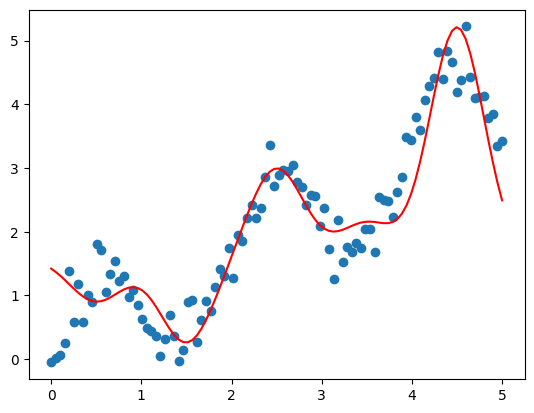

In [33]:
plt.scatter(x,y)
plt.plot(x, regr_rbf.predict(X_rbf), 'r')

In [34]:
print('Coefficients: ', regr_rbf.coef_)
print('interception: ', regr_rbf.intercept_)

Coefficients:  [-0.6835053  -1.33303386  1.40579248  0.54664724  3.61673701]
interception:  1.591463347999908


#### Comparison

In [36]:
y_pred_lin = regr_lin.predict(X)
y_pred_poly = regr_poly.predict(X_poly)
y_pred_rbf = regr_rbf.predict(X_rbf)

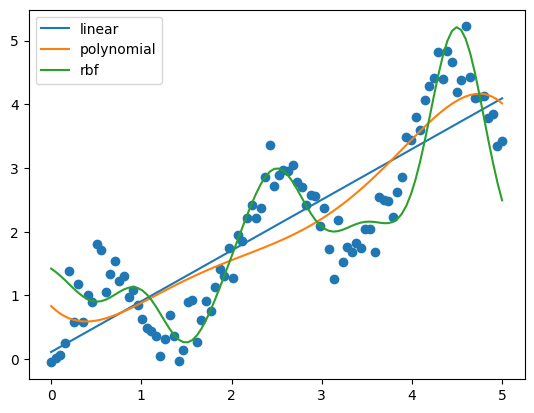

In [37]:
plt.scatter(x,y)

plt.plot(x, y_pred_lin, label='linear')
plt.plot(x, y_pred_poly, label='polynomial')
plt.plot(x, y_pred_rbf, label='rbf')
plt.legend()

## 請計算模型的MSE

In [38]:
print(np.sum((regr_lin.predict(X)-y)**2) / len(y))

0.4989949775676724


In [39]:
print(np.sum((regr_poly.predict(X_poly)-y)**2) / len(y))

0.44529099471624756


In [40]:
print(np.sum((regr_rbf.predict(X_rbf)-y)**2) / len(y))

0.24107351381301165
